<a href="https://colab.research.google.com/github/miftahulhdd/MiftahulHudaAmri_2411533005_ML2526/blob/main/praktikum6/Tugaspert6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X = X[['mean radius', 'mean texture']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
y_pred_no_scale = knn_no_scale.predict(X_test)
print(accuracy_score(y_test, y_pred_no_scale))

0.9035087719298246


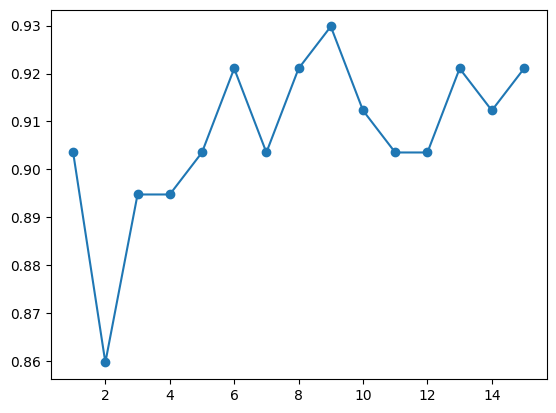

In [4]:
k_values = list(range(1, 16))
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.show()

In [5]:
c_values = [0.1, 1, 10]
gamma_values = ['scale', 'auto']
for c in c_values:
    for gamma in gamma_values:
        svm_model = SVC(C=c, gamma=gamma)
        svm_model.fit(X_train_scaled, y_train)
        y_pred = svm_model.predict(X_test_scaled)
        print(c, gamma, accuracy_score(y_test, y_pred))

0.1 scale 0.9035087719298246
0.1 auto 0.9035087719298246
1 scale 0.9210526315789473
1 auto 0.9210526315789473
10 scale 0.9122807017543859
10 auto 0.9122807017543859


In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn_cv = cross_val_score(knn, X_train_scaled, y_train, cv=kf)
print(np.mean(knn_cv))

svm_linear = SVC(kernel='linear')
svm_linear_cv = cross_val_score(svm_linear, X_train_scaled, y_train, cv=kf)
print(np.mean(svm_linear_cv))

svm_rbf = SVC(kernel='rbf')
svm_rbf_cv = cross_val_score(svm_rbf, X_train_scaled, y_train, cv=kf)
print(np.mean(svm_rbf_cv))

0.8857142857142858
0.8813186813186812
0.9010989010989011
